# vera DETR 하이퍼파라미터 튜닝 노트북
- LR 튜닝 결과: 기준(1e-5/1e-4)이 최적
- 이 노트북: weight_decay 튜닝

In [1]:
# ============================================================
# [Cell 0] 환경 세팅
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, sys

REPO_DIR = '/content/pill_detection_project'
if not os.path.exists(REPO_DIR):
    os.system(f'git clone https://github.com/wina0901/pill_detection_project.git {REPO_DIR}')

sys.path.insert(0, REPO_DIR)

BASE_DIR = '/content/drive/MyDrive/data/초급_프로젝트/dataset'
EXP_DIR  = '/content/drive/MyDrive/vera_detr/experiments'
VAL_JSON = f'{BASE_DIR}/val_letterbox.json'

os.makedirs(EXP_DIR, exist_ok=True)

print(f'✅ BASE_DIR : {BASE_DIR}')
print(f'✅ EXP_DIR  : {EXP_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ BASE_DIR : /content/drive/MyDrive/data/초급_프로젝트/dataset
✅ EXP_DIR  : /content/drive/MyDrive/vera_detr/experiments


In [2]:
# ============================================================
# [Cell 1] 패키지 설치
# ============================================================
!pip install transformers timm pycocotools torchmetrics -q

In [3]:
# ============================================================
# [Cell 2] 팀 평가 모듈 import
# ============================================================
from src.evaluation import (
    evaluate_all,
    init_history,
    update_history,
    save_history,
    load_history,
    plot_training_history,
    plot_compare_histories,
)

print('✅ 팀 평가 모듈 로드 완료')

✅ 팀 평가 모듈 로드 완료


In [4]:
# ============================================================
# [Cell 3] Dataset / DataLoader
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import json

class DETRDataset(Dataset):
    def __init__(self, json_path, img_dir, transforms=None):
        with open(json_path, 'r') as f:
            coco = json.load(f)
        self.img_dir     = img_dir
        self.transforms  = transforms
        self.images      = {img['id']: img for img in coco['images']}
        cats             = sorted([c['id'] for c in coco['categories']])
        self.cat2idx     = {c: i for i, c in enumerate(cats)}
        self.num_classes = len(cats)
        self.img_ids     = list(self.images.keys())
        self.annots      = {img_id: [] for img_id in self.img_ids}
        for ann in coco['annotations']:
            if ann['image_id'] in self.annots:
                self.annots[ann['image_id']].append(ann)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.images[img_id]
        image    = Image.open(os.path.join(self.img_dir, img_info['file_name'])).convert('RGB')
        W, H     = image.size
        boxes, labels = [], []
        for ann in self.annots[img_id]:
            x, y, w, h = ann['bbox']
            boxes.append([(x+w/2)/W, (y+h/2)/H, w/W, h/H])
            labels.append(self.cat2idx[ann['category_id']])
        target = {
            'boxes':    torch.tensor(boxes,  dtype=torch.float32),
            'labels':   torch.tensor(labels, dtype=torch.long),
            'image_id': torch.tensor([img_id])
        }
        if self.transforms:
            image = self.transforms(image)
        return image, target

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images), list(targets)

train_dataset = DETRDataset(
    json_path=f'{BASE_DIR}/train_letterbox.json',
    img_dir=f'{BASE_DIR}/letterbox_images/train',
    transforms=transform
)
val_dataset = DETRDataset(
    json_path=VAL_JSON,
    img_dir=f'{BASE_DIR}/letterbox_images/val',
    transforms=transform
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

idx2cat = {v: k for k, v in train_dataset.cat2idx.items()}

print(f'✅ train: {len(train_dataset)}장 / val: {len(val_dataset)}장')
print(f'✅ 클래스 수: {train_dataset.num_classes}')

✅ train: 1792장 / val: 139장
✅ 클래스 수: 73


In [5]:
# ============================================================
# [Cell 4] device 설정
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ device: {device}')

✅ device: cuda


In [6]:
# ============================================================
# [Cell 5] 유틸 함수
# ============================================================
from transformers import DetrForObjectDetection
from torch.optim import AdamW

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience  = patience
        self.counter   = 0
        self.best_loss = float('inf')
        self.stop      = False

    def step(self, loss):
        if loss < self.best_loss:
            self.best_loss = loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return self.stop

# 학습 함수
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for images, targets in loader:
        images = images.to(device)
        labels = [{'class_labels': t['labels'].to(device),
                   'boxes':        t['boxes'].to(device)} for t in targets]
        outputs = model(pixel_values=images, labels=labels)
        loss    = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# DETR 출력 → evaluate_all 변환
def convert_detr_outputs(model, loader, device, score_threshold=0.001):
    predictions = []
    model.eval()
    with torch.no_grad():
        for images, targets in loader:
            images  = images.to(device)
            outputs = model(pixel_values=images)
            for i, target in enumerate(targets):
                image_id   = target['image_id'].item()
                W, H       = 800, 800
                logits     = outputs.logits[i]
                boxes      = outputs.pred_boxes[i]
                scores_all = logits.softmax(-1)
                scores, labels = scores_all[:, :-1].max(-1)
                for score, label, box in zip(scores, labels, boxes):
                    score = score.item()
                    if score < score_threshold:
                        continue
                    cx, cy, bw, bh = box.tolist()
                    predictions.append({
                        'image_id':    image_id,
                        'category_id': idx2cat.get(label.item(), label.item()),
                        'bbox_xyxy':   [
                            (cx - bw/2) * W, (cy - bh/2) * H,
                            (cx + bw/2) * W, (cy + bh/2) * H,
                        ],
                        'score': score,
                    })
    return predictions

print('✅ 유틸 함수 준비 완료')

✅ 유틸 함수 준비 완료


In [7]:
# ============================================================
# [Cell 6] run_experiment 함수 (weight_decay 파라미터 추가)
# ============================================================
def run_experiment(backbone_lr=1e-5, cls_lr=1e-4, weight_decay=1e-4, epochs=30):
    config   = {'backbone_lr': backbone_lr, 'cls_lr': cls_lr,
                'weight_decay': weight_decay, 'epochs': epochs}
    exp_name = f'backbone{backbone_lr}_cls{cls_lr}_wd{weight_decay}'
    print(f'\n🚀 실험 시작: {config}')

    model = DetrForObjectDetection.from_pretrained(
        'facebook/detr-resnet-50',
        num_labels=73,
        ignore_mismatched_sizes=True
    ).to(device)

    optimizer = AdamW([
        {'params': model.model.parameters(),                  'lr': backbone_lr},
        {'params': model.class_labels_classifier.parameters(),'lr': cls_lr},
    ], weight_decay=weight_decay)

    early_stopping = EarlyStopping(patience=10)
    train_losses   = []

    for epoch in range(1, epochs + 1):
        loss = train_one_epoch(model, train_loader, optimizer, device)
        train_losses.append(round(loss, 4))
        print(f'Epoch [{epoch}/{epochs}] Loss: {loss:.4f}')

        if early_stopping.step(loss):
            print(f'⏹️  Early Stopping @ epoch {epoch}')
            break

    # 가중치 저장
    torch.save(model.state_dict(), f'{EXP_DIR}/{exp_name}.pth')

    # train log 저장
    with open(f'{EXP_DIR}/{exp_name}_train_log.json', 'w') as f:
        json.dump({'config': config, 'train_losses': train_losses,
                   'stopped_epoch': epoch}, f, indent=2)

    # 평가
    print(f'\n📊 평가 중...')
    val_predictions = convert_detr_outputs(model, val_loader, device)
    metrics = evaluate_all(
        gt_json_path=VAL_JSON,
        predictions=val_predictions,
        conf_threshold=0.25,
        pr_iou_threshold=0.5,
        temp_json_path=f'detr_temp_{exp_name}.json'
    )

    # history 저장
    history = init_history()
    for ep, tl in enumerate(train_losses, 1):
        update_history(history, epoch=ep, train_loss=tl)
    history['mAP@50'][-1]    = metrics['mAP@50']
    history['mAP@75:95'][-1] = metrics['mAP@75:95']
    history['precision'][-1] = metrics['precision']
    history['recall'][-1]    = metrics['recall']
    save_history(history, f'{EXP_DIR}/history_{exp_name}.json')

    print(f'\n✅ [{exp_name}] 결과')
    print(f'   mAP@50    : {metrics["mAP@50"]:.4f}')
    print(f'   mAP@75:95 : {metrics["mAP@75:95"]:.4f}')
    print(f'   precision : {metrics["precision"]:.4f}')
    print(f'   recall    : {metrics["recall"]:.4f}')
    print(f'   저장 완료 → {exp_name}.pth')

    return model, metrics

print('✅ run_experiment 준비 완료')

✅ run_experiment 준비 완료


## weight_decay 튜닝

| 실험 | backbone_lr | cls_lr | weight_decay | 목적 |
|---|---|---|---|---|
| 기준 | 1e-5 | 1e-4 | 1e-4 | 완료 ✅ |
| 실험 3 | 1e-5 | 1e-4 | 1e-3 | 규제 강하게 |
| 실험 4 | 1e-5 | 1e-4 | 1e-5 | 규제 약하게 |

In [8]:
# ============================================================
# [Cell 7] 실험 3 — weight_decay 1e-3 (규제 강하게)
# ============================================================
model_exp3, metrics_exp3 = run_experiment(
    backbone_lr=1e-5,
    cls_lr=1e-4,
    weight_decay=1e-3
)


🚀 실험 시작: {'backbone_lr': 1e-05, 'cls_lr': 0.0001, 'weight_decay': 0.001, 'epochs': 30}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the

Epoch [1/30] Loss: 1.8752
Epoch [2/30] Loss: 1.2492
Epoch [3/30] Loss: 1.1160
Epoch [4/30] Loss: 1.0193
Epoch [5/30] Loss: 0.8983
Epoch [6/30] Loss: 0.7799
Epoch [7/30] Loss: 0.7110
Epoch [8/30] Loss: 0.6409
Epoch [9/30] Loss: 0.5808
Epoch [10/30] Loss: 0.5182
Epoch [11/30] Loss: 0.4714
Epoch [12/30] Loss: 0.4416
Epoch [13/30] Loss: 0.4572
Epoch [14/30] Loss: 0.5105
Epoch [15/30] Loss: 0.3983
Epoch [16/30] Loss: 0.3388
Epoch [17/30] Loss: 0.3630
Epoch [18/30] Loss: 0.3732
Epoch [19/30] Loss: 0.3630
Epoch [20/30] Loss: 0.3020
Epoch [21/30] Loss: 0.3417
Epoch [22/30] Loss: 0.3403
Epoch [23/30] Loss: 0.3129
Epoch [24/30] Loss: 0.3357
Epoch [25/30] Loss: 0.2938
Epoch [26/30] Loss: 0.2772
Epoch [27/30] Loss: 0.2671
Epoch [28/30] Loss: 0.2645
Epoch [29/30] Loss: 0.2491
Epoch [30/30] Loss: 0.2719

📊 평가 중...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evalua

In [9]:
# ============================================================
# [Cell 8] 실험 4 — weight_decay 1e-5 (규제 약하게)
# ============================================================
model_exp4, metrics_exp4 = run_experiment(
    backbone_lr=1e-5,
    cls_lr=1e-4,
    weight_decay=1e-5
)


🚀 실험 시작: {'backbone_lr': 1e-05, 'cls_lr': 0.0001, 'weight_decay': 1e-05, 'epochs': 30}


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

Epoch [1/30] Loss: 1.9884
Epoch [2/30] Loss: 1.4535
Epoch [3/30] Loss: 1.1884
Epoch [4/30] Loss: 1.0411
Epoch [5/30] Loss: 0.8996
Epoch [6/30] Loss: 0.7829
Epoch [7/30] Loss: 0.7023
Epoch [8/30] Loss: 0.6369
Epoch [9/30] Loss: 0.5701
Epoch [10/30] Loss: 0.4765
Epoch [11/30] Loss: 0.4438
Epoch [12/30] Loss: 0.4070
Epoch [13/30] Loss: 0.3967
Epoch [14/30] Loss: 0.4247
Epoch [15/30] Loss: 0.3548
Epoch [16/30] Loss: 0.3507
Epoch [17/30] Loss: 0.3103
Epoch [18/30] Loss: 0.3037
Epoch [19/30] Loss: 0.2914
Epoch [20/30] Loss: 0.2650
Epoch [21/30] Loss: 0.2710
Epoch [22/30] Loss: 0.2886
Epoch [23/30] Loss: 0.2670
Epoch [24/30] Loss: 0.2599
Epoch [25/30] Loss: 0.2798
Epoch [26/30] Loss: 0.2900
Epoch [27/30] Loss: 0.2816
Epoch [28/30] Loss: 0.2613
Epoch [29/30] Loss: 0.2524
Epoch [30/30] Loss: 0.2378

📊 평가 중...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evalua

In [10]:
# ============================================================
# [Cell 9] 전체 실험 결과 비교
# ============================================================
# 기준 실험 결과 (직접 입력)
baseline = {
    'exp':        '기준 (wd=1e-4)',
    'mAP@50':     0.8565,
    'mAP@75:95':  0.8317,
    'precision':  None,
    'recall':     None,
}

results = [
    baseline,
    {'exp': '실험3 (wd=1e-3)', **{k: metrics_exp3[k] for k in ['mAP@50','mAP@75:95','precision','recall']}},
    {'exp': '실험4 (wd=1e-5)', **{k: metrics_exp4[k] for k in ['mAP@50','mAP@75:95','precision','recall']}},
]

print('\n' + '='*65)
print(f'{"실험":<20} {"mAP@50":>10} {"mAP@75:95":>12} {"precision":>10} {"recall":>8}')
print('='*65)
for r in results:
    p = f"{r['precision']:.4f}" if r['precision'] else '  -   '
    rc = f"{r['recall']:.4f}" if r['recall'] else '  -   '
    print(f"{r['exp']:<20} {r['mAP@50']:>10.4f} {r['mAP@75:95']:>12.4f} {p:>10} {rc:>8}")
print('='*65)


실험                       mAP@50    mAP@75:95  precision   recall
기준 (wd=1e-4)             0.8565       0.8317       -        -   
실험3 (wd=1e-3)            0.8423       0.7923     0.7792   0.9582
실험4 (wd=1e-5)            0.8548       0.8108     0.7921   0.9722


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


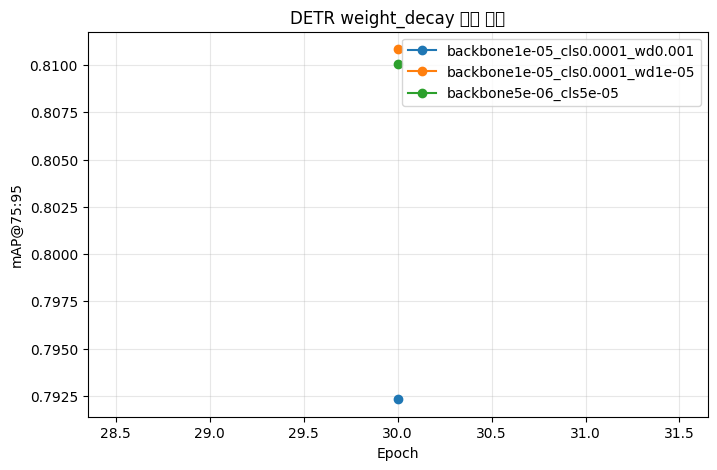

In [11]:
# ============================================================
# [Cell 10] 시각화 비교
# ============================================================
histories = []
labels    = []

for fname in sorted(os.listdir(EXP_DIR)):
    if fname.startswith('history_') and fname.endswith('.json'):
        h = load_history(f'{EXP_DIR}/{fname}')
        histories.append(h)
        labels.append(fname.replace('history_', '').replace('.json', ''))

if histories:
    plot_compare_histories(
        histories=histories,
        labels=labels,
        metric_key='mAP@75:95',
        title='DETR weight_decay 튜닝 비교'
    )